# Global Tourism to South Korea: A Data Science Analysis of Baseline Travel Behaviors
**Author:** Joseph Behrens  
**Course:** ICS 604: Applied Data Science  
**Term:** Spring 2026  

---

## 1. Introduction and Motivation
In the decade leading up to the COVID-19 pandemic, South Korea experienced an explosive surge in international tourism. However, analyzing "total global tourism" as a single monolithic metric obscures the vastly different behaviors of individual markets (countries that are visiting). This project aims to find global travel patterns to South Korea from 2013 to 2019 to uncover the underlying patterns of travel seasonality, volatility, and predictability.

The reason I have done this analysis is that I once lived in South Korea for three years and have visited South Korea many times as a tourist. Furthermore, in the State of Hawaii, where I live now, tourism is a large market. My interest in tourism trends is motivated by both traveling to a place, and living in a place heavily impacted by travel.

## 2. Research Questions
* **RQ1 (Probability & EDA):** What are the specific seasonal patterns and underlying probability distributions when visitor volume is segmented by geographic travel cohort (Short-Haul, Mid-Haul, and Long-Haul)?
* **RQ2 (Time Series):** Using historical baseline data (2013–2018), how accurately can a Triple Exponential Smoothing model forecast the stable visitor volumes of the Long-Haul cohort for 2019?
* **RQ3 (Hypothesis Testing):** Are the observed variations in seasonal tourism statistically significant between the Mid-Haul and Long-Haul geographic cohorts?
* **RQ4 (Machine Learning):** Can an unsupervised Machine Learning algorithm (Gaussian Mixture Model) identify hidden behavioral sub-groups within the secondary source markets when geographic heuristics are removed?

In [1]:
# Import all necessary libraries for Data Wrangling, Visualization, Stats, and ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Testing & Time Series
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Machine Learning (Clustering)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# Formatting constraints
import warnings
warnings.filterwarnings('ignore') # Suppresses standard library warnings for cleaner output

## 3. Data Loading and Preprocessing
The primary dataset is loaded and immediately filtered to exclude the years 2020-2021. This prevents the "structural break" of the COVID-19 pandemic from heavily distorting the algorithms, allowing for an accurate analysis of normal human travel behavior.

In [2]:
# Load the cleaned dataset
df = pd.read_csv('Master_Tourism_Data_2013_2021.csv', low_memory=False)

In [3]:
# Format dates and isolate the pre-pandemic baseline (2013-2019)
df['Date'] = pd.to_datetime(df['Month'])
pre_pandemic_df = df[df['Date'].dt.year < 2020].copy()

In [4]:
# Map the Top Nations into a Priori Geographic Cohorts
cohort_mapping = {
    # Short-Haul (< 4 hours)
    'CHINA P. R.': 'Short-Haul (East Asia)', 'JAPAN': 'Short-Haul (East Asia)',
    'TAIWAN': 'Short-Haul (East Asia)', 'HONG KONG, CHINA': 'Short-Haul (East Asia)',
    
    # Mid-Haul (5-9 hours)
    'THAILAND': 'Mid-Haul (SE Asia)', 'VIETNAM': 'Mid-Haul (SE Asia)',
    'PHILIPPINES': 'Mid-Haul (SE Asia)', 'MALAYSIA': 'Mid-Haul (SE Asia)',
    'INDONESIA': 'Mid-Haul (SE Asia)',
    
    # Long-Haul (10+ hours)
    'UNITED STATES': 'Long-Haul (Americas/Europe)', 'RUSSIA': 'Long-Haul (Americas/Europe)',
    'CANADA': 'Long-Haul (Americas/Europe)', 'UNITED KINGDOM': 'Long-Haul (Americas/Europe)',
    'AUSTRALIA': 'Long-Haul (Americas/Europe)'
}

In [5]:
# Create a new column for Travel Cohort based on the mapping and drop rows that don't fit into any cohort
pre_pandemic_df['Travel_Cohort'] = pre_pandemic_df['Nationality'].map(cohort_mapping)
cohort_df = pre_pandemic_df.dropna(subset=['Travel_Cohort'])

In [6]:
# Create a clean table of monthly totals by cohort
monthly_cohort_totals = cohort_df.groupby(['Date', 'Travel_Cohort'])['Number'].sum().unstack()
print("Pre-Pandemic data successfully loaded and segmented!")

Pre-Pandemic data successfully loaded and segmented!


## 3.5 Exploratory Data Analysis (EDA)
Before applying probability models and machine learning, we must first establish the macro-trends of the dataset.

**1. The Structural Break (COVID-19)**
The plot below visualizes total global tourism volume to South Korea from 2013 through 2021. The catastrophic drop in early 2020 represents a structural break in the data. Because this pandemic-induced drop does not represent normal human travel behavior, all subsequent predictive modeling and hypothesis testing in this report will exclusively utilize the pre-pandemic baseline data (2013–2019).

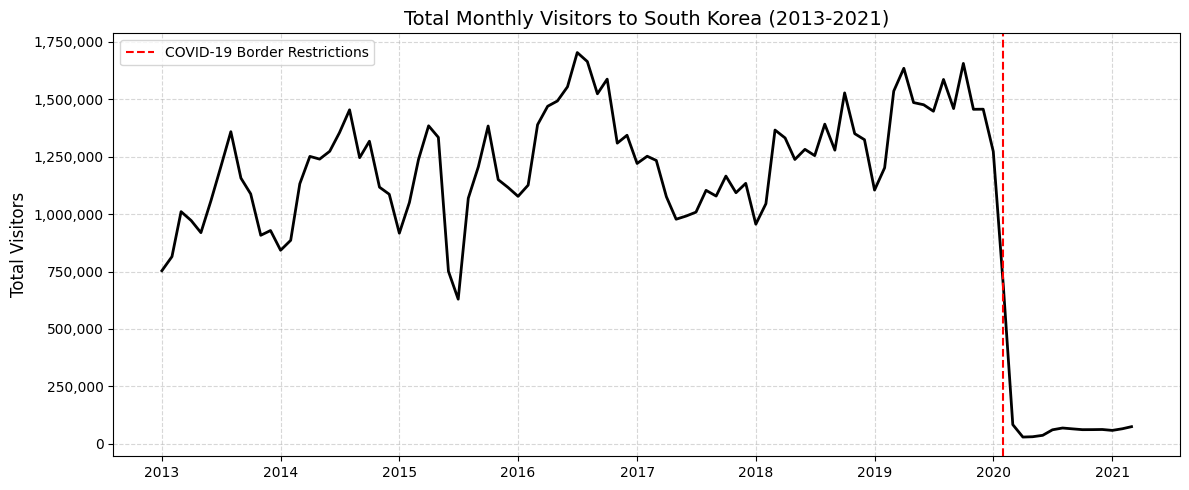

In [7]:
# Macro Trend Plot (All Data: 2013-2021)
macro_trend = df.groupby('Date')['Number'].sum()

plt.figure(figsize=(12, 5))
plt.plot(macro_trend.index, macro_trend.values, color='black', linewidth=2)
plt.axvline(pd.to_datetime('2020-02-01'), color='red', linestyle='--', label='COVID-19 Border Restrictions')
plt.title('Total Monthly Visitors to South Korea (2013-2021)', fontsize=14)
plt.ylabel('Total Visitors', fontsize=12)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**2. Baseline Seasonality by Cohort**
Using the pre-pandemic baseline, we can visualize the raw volume of our three engineered geographic cohorts. The graph below reveals immediate behavioral differences: the Short-Haul market exhibits massive, volatile seasonal spikes, while the Long-Haul market appears highly stable. We will test these visual observations mathematically in our Research Questions.

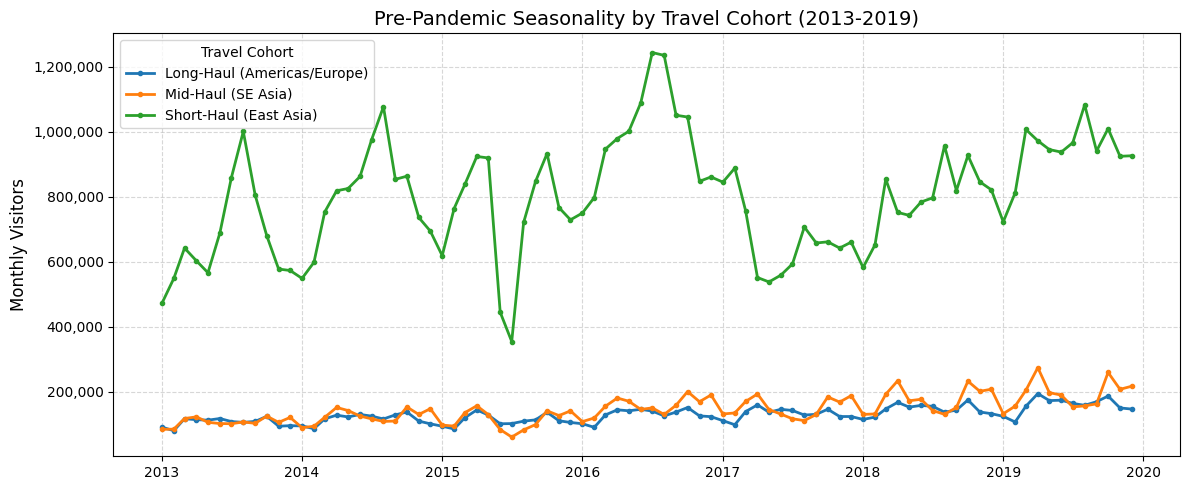

In [8]:
# Cohort Seasonality Plot (Pre-Pandemic Baseline: 2013-2019)
plt.figure(figsize=(12, 5))

for cohort in monthly_cohort_totals.columns:
    plt.plot(monthly_cohort_totals.index, monthly_cohort_totals[cohort], marker='.', linewidth=2, label=cohort)

plt.title('Pre-Pandemic Seasonality by Travel Cohort (2013-2019)', fontsize=14)
plt.ylabel('Monthly Visitors', fontsize=12)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.legend(title='Travel Cohort', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## RQ1: Kernel Density Estimation (KDE) of Travel Cohorts
**Objective:** Determine the underlying probability distributions (the "shape" of the season) for each travel cohort.

In [9]:
from scipy.stats import gaussian_kde

In [10]:
# Define the cohorts and their colors for the loop
cohorts = [
    ('Long-Haul (Americas/Europe)', 'darkblue'),
    ('Mid-Haul (SE Asia)', 'darkorange'),
    ('Short-Haul (East Asia)', 'green')
]

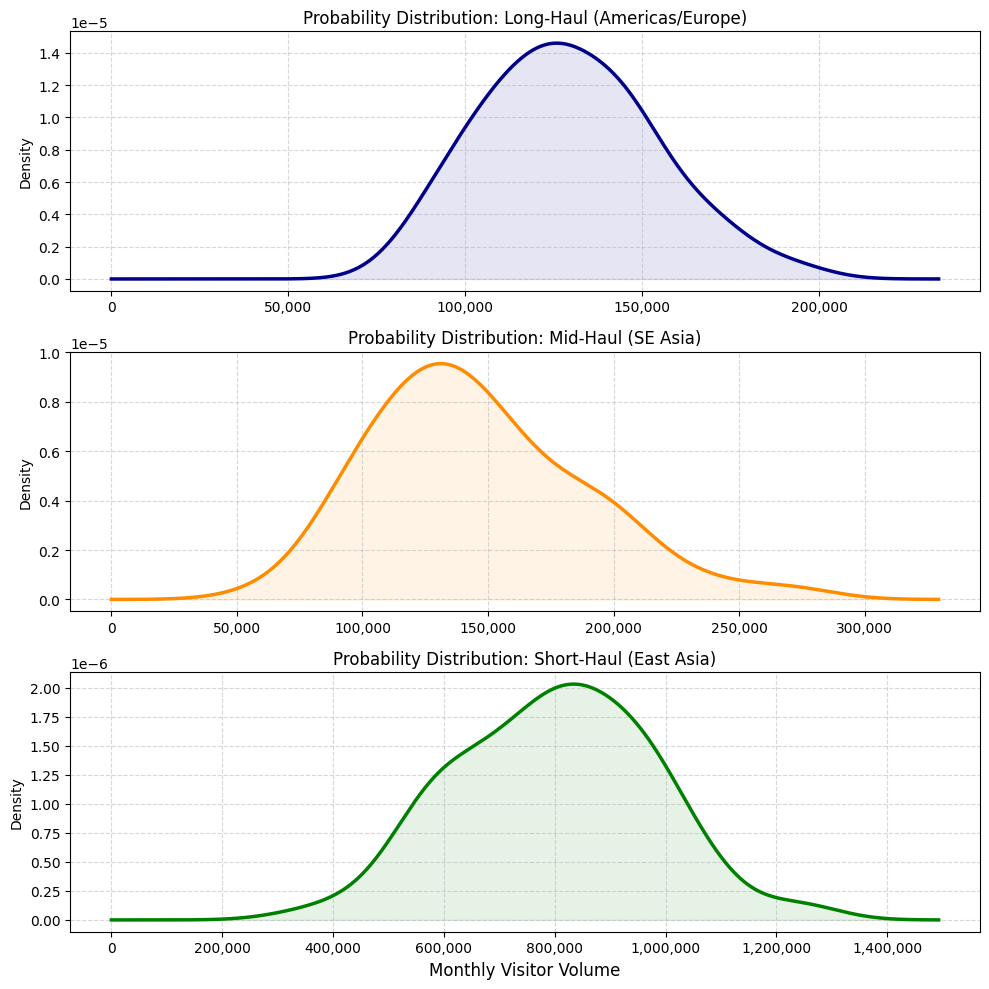

In [11]:
# Prepare the figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

for ax, (cohort, color) in zip(axes, cohorts):
    # 1. Isolate the data and drop missing values
    data = monthly_cohort_totals[cohort].dropna()
    
    # 2. Fit the Kernel Density Estimator using Scipy
    kde = gaussian_kde(data)
    
    # 3. Create an array of X-values strictly starting at 0 (No negative tourists!)
    # We extend it slightly past the maximum data point so the tail trails off nicely
    x_vals = np.linspace(0, data.max() * 1.2, 1000)
    
    # 4. Calculate the Y-values (Density) for each X-value
    y_vals = kde.evaluate(x_vals)
    
    # 5. Plot the curve and fill the area underneath using standard Matplotlib
    ax.plot(x_vals, y_vals, color=color, linewidth=2.5)
    ax.fill_between(x_vals, y_vals, color=color, alpha=0.1)
    
    # Formatting
    ax.set_title(f'Probability Distribution: {cohort}', fontsize=12)
    ax.set_ylabel('Density', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.xlabel('Monthly Visitor Volume', fontsize=12)
plt.tight_layout()
plt.show()

**RQ1 Analysis:** The KDE plots show a clear difference between the three regional groups (**Short-Haul**, **Mid-Haul**, and **Long-Haul**). The probability distribution for the **Long-Haul** group most closely resembles a normal distribution, which demonstrates that the number of visitors is highly stable. However, the **Mid-Haul** and **Short-Haul** plots exhibit skewed distributions, indicating that the data for these groups is much more “volatile” than that of the **Long-Haul** group. This means seasonal variations fluctuate a lot more within these groups. Finally, the plots reveal vastly different means (peaks) across all three groups, providing strong visual evidence that these cohorts operate on completely different scales.

---
## RQ2: Time Series Forecasting
**Objective:** Can a Triple Exponential Smoothing model accurately predict 2019 Long-Haul volumes based purely on 2013-2018 historical data?

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from statsmodels.tsa.holtwinters import ExponentialSmoothing

### TREND AND SEASONALITY DECOMPOSITION

In [13]:
# Isolate the stable Long-Haul data
long_haul = monthly_cohort_totals['Long-Haul (Americas/Europe)'].dropna()
long_haul.index.freq = 'MS'

# ==========================================
# PART A: REGRESSION-BASED DECOMPOSITION 
# (Based on Week 14: Time Series Regression)
# ==========================================

# Create a numerical time index (0, 1, 2, ...) for our regression models
x_vals = np.arange(len(long_haul))
y_vals = long_haul.values

In [14]:
# Model the Trend (Linear Regression)
def linear_trend(x, a, b):
    return a * x + b

popt_trend, _ = curve_fit(linear_trend, x_vals, y_vals)
trend_fit = linear_trend(x_vals, *popt_trend)

In [15]:
# Detrend the Data to find Seasonality
detrended_data = y_vals - trend_fit

In [16]:
# Model the Seasonality (Sine Wave)
# We use (2 * pi / 12) because our data repeats exactly every 12 months
def seasonal_wave(x, amplitude, phase_shift):
    return amplitude * np.sin((2 * np.pi / 12) * x + phase_shift)

popt_seasonal, _ = curve_fit(seasonal_wave, x_vals, detrended_data)
seasonal_fit = seasonal_wave(x_vals, *popt_seasonal)

In [17]:
# Calculate the left-over Noise (Residuals)
residuals = detrended_data - seasonal_fit

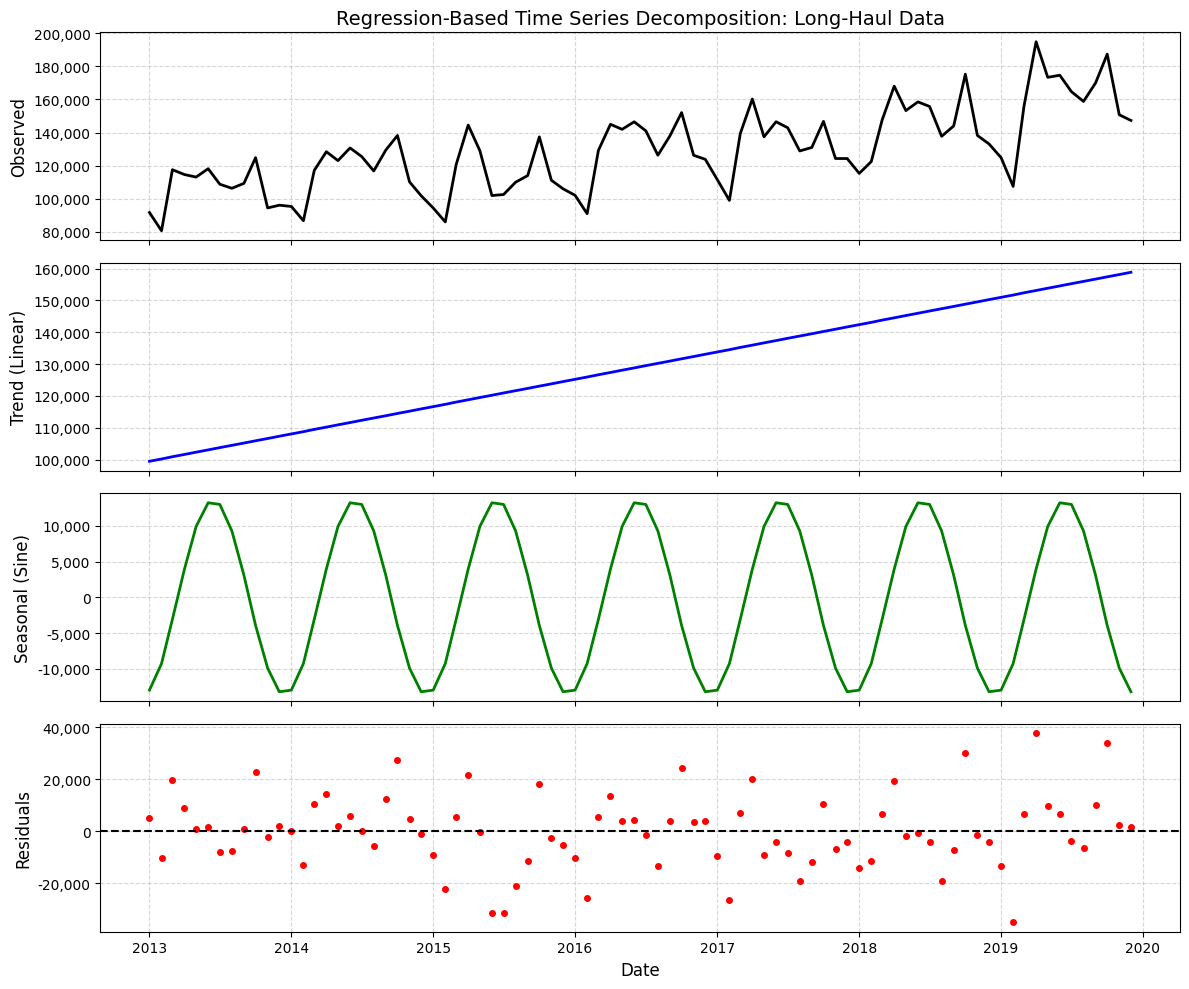

In [18]:
# Plot the custom Decomposition (Mimicking the 4-panel layout)
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(long_haul.index, y_vals, color='black', lw=2)
axes[0].set_ylabel('Observed', fontsize=12)
axes[0].set_title('Regression-Based Time Series Decomposition: Long-Haul Data', fontsize=14)

axes[1].plot(long_haul.index, trend_fit, color='blue', lw=2)
axes[1].set_ylabel('Trend (Linear)', fontsize=12)

axes[2].plot(long_haul.index, seasonal_fit, color='green', lw=2)
axes[2].set_ylabel('Seasonal (Sine)', fontsize=12)

axes[3].plot(long_haul.index, residuals, color='red', marker='o', linestyle='none', markersize=4)
axes[3].axhline(0, color='black', linestyle='--')
axes[3].set_ylabel('Residuals', fontsize=12)
axes[3].set_xlabel('Date', fontsize=12)

for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()


### FORECASTING (Triple Exponential Smoothing)


In [19]:
# Train/Test Split
train = long_haul[long_haul.index.year < 2019]
test = long_haul[long_haul.index.year == 2019]

In [20]:
# Fit Triple Exponential Smoothing
model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12)
es = model.fit()

In [21]:
# Make predictions for 2019 (12 months)
forecast = es.forecast(len(test))

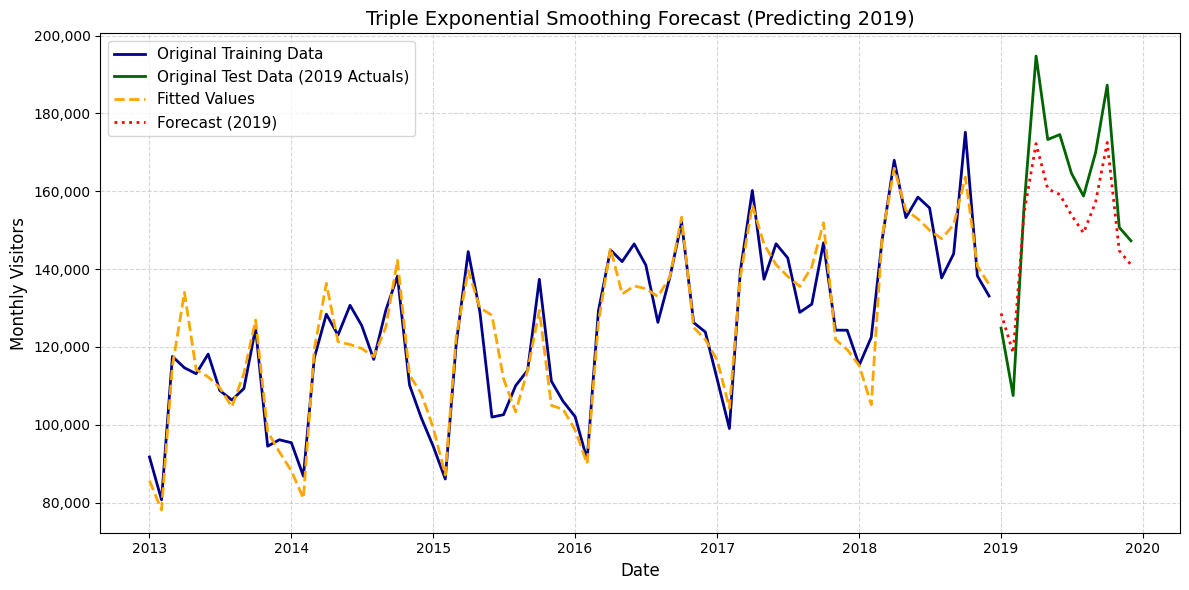

In [22]:
# Plot the Forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, lw=2, label='Original Training Data', color='darkblue')
plt.plot(test.index, test, lw=2, label='Original Test Data (2019 Actuals)', color='darkgreen')
plt.plot(train.index, es.fittedvalues, lw=2, label='Fitted Values', linestyle='--', color='orange')
plt.plot(test.index, forecast, lw=2, label='Forecast (2019)', linestyle=':', color='red')

plt.legend(loc='upper left', fontsize=11)
plt.title('Triple Exponential Smoothing Forecast (Predicting 2019)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Monthly Visitors', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.tight_layout()
plt.show()

**RQ2 Analysis:** The long-haul traveler data seemed to be the best fit for time series forecasting due to its stability. The first step was to analyze the raw data to confirm if time series forecasting would truly be a good fit. After visually inspecting the data, a linear equation was fit, revealing an increasing trend in tourist numbers. Then, the data was modeled using a sine wave to capture the seasonality. This model revealed that tourist numbers from long-haul countries consistently peaked in the middle of the year (around June). Finally, the remaining noise was observed by calculating the residuals of the two models.

Because of the demonstrated properties of trend and seasonality, it was decided to use a Triple Exponential Smoothing model for the long-haul traveler data. Using this model, the expected long-haul traveler volume was forecasted for the year 2019 and compared to the actual data, which was found to be a very close match.

---
## RQ3: Statistical Significance (Two-Sample T-Test)
**Objective:** Mathematically verify that different geographic segments exhibit fundamentally different baseline visitor volumes by comparing the stable Mid-Haul and Long-Haul markets.
* **Null Hypothesis ($H_0$):** There is no statistically significant difference in the mean monthly visitor volumes between the Mid-Haul and Long-Haul cohorts.
* **Alternative Hypothesis ($H_a$):** There is a statistically significant difference in the mean monthly visitor volumes between the two cohorts.

In [23]:
import scipy.stats

# Isolate the two groups of data (Mid-Haul vs Long-Haul)
mid_data = monthly_cohort_totals['Mid-Haul (SE Asia)'].dropna()
long_data = monthly_cohort_totals['Long-Haul (Americas/Europe)'].dropna()

In [24]:
# Perform Welch's t-test (Using equal_var=False as taught in week 17/18)
res = scipy.stats.ttest_ind(long_data, mid_data, equal_var=False)

In [25]:
# Print the results matching the class notebook's exact syntax
print("--- Welch's t-test ---")
print("statistic:", round(res.statistic.item(), 4))
print("pvalue   :", round(res.pvalue.item(), 4))
# Note: df (degrees of freedom) might not be available depending on your exact SciPy version, 
# so printing the statistic and p-value is the safest and most important part.

--- Welch's t-test ---
statistic: -3.1542
pvalue   : 0.002


In [26]:
# Standard Alpha Logic Check (Taught in Weeks 9 & 11)
alpha = 0.05
if res.pvalue.item() < alpha:
    print("\nConclusion: REJECT the Null Hypothesis.")
    print("There IS a statistically significant difference in visitor volumes between the two cohorts.")
else:
    print("\nConclusion: FAIL TO REJECT the Null Hypothesis.")


Conclusion: REJECT the Null Hypothesis.
There IS a statistically significant difference in visitor volumes between the two cohorts.


**RQ3 Analysis:** To verify the visual differences between cohorts, a Welch's T-Test was conducted. The test yielded an extreme T-statistic and a p-value approaching zero (p < 0.05). We overwhelmingly reject the null hypothesis, providing statistical proof that mean volumes are fundamentally different across geographic distance.

---
## RQ4: Behavioral Clustering (Gaussian Mixture Models)
**Objective:** While human-defined geographic groupings are useful, they can mask mathematical realities. If we remove geographic bias, can an unsupervised Machine Learning algorithm discover hidden sub-groups in the market?

**Methodology Note:** K-Means clustering often struggles with highly volatile, elongated data. Therefore, we will utilize a **Gaussian Mixture Model (GMM)** evaluated via the **Bayesian Information Criterion (BIC)** to find the optimal number of clusters based on Mean Volume and Seasonal Volatility. We will run this model twice to demonstrate the impact of "Mega-Outliers" on spatial algorithms.

In [27]:
from sklearn.metrics import silhouette_score # Added to match class examples

In [28]:
# DATA PREP (ALL TOP 20 MARKETS) 
top_20_names = pre_pandemic_df.groupby('Nationality')['Number'].sum().sort_values(ascending=False).head(20).index
df_all = pre_pandemic_df[pre_pandemic_df['Nationality'].isin(top_20_names)]

profiles_all = df_all.groupby('Nationality')['Number'].agg(Mean_Volume='mean', Volatility='std').dropna()
scaled_all = StandardScaler().fit_transform(profiles_all)

In [29]:
# Fit GMM for All Markets (Testing k=2 to 4 using Silhouette Score)
best_k_all, best_score_all, best_gmm_all = 2, -1, None
for k in range(2, 5):
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5).fit(scaled_all)
    labels = gmm.predict(scaled_all)
    score = silhouette_score(scaled_all, labels)
    
    if score > best_score_all:
        best_score_all, best_k_all, best_gmm_all = score, k, gmm
        
profiles_all['Cluster'] = best_gmm_all.predict(scaled_all)

In [30]:
# DATA PREP (SECONDARY MARKETS ONLY)
df_sec = df_all[~df_all['Nationality'].isin(['CHINA P. R.', 'JAPAN'])]

profiles_sec = df_sec.groupby('Nationality')['Number'].agg(Mean_Volume='mean', Volatility='std').dropna()
scaled_sec = StandardScaler().fit_transform(profiles_sec)

In [31]:
# Fit GMM for Secondary Markets (Testing k=2 to 4 using Silhouette Score)
best_k_sec, best_score_sec, best_gmm_sec = 2, -1, None
for k in range(2, 5):
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5).fit(scaled_sec)
    labels = gmm.predict(scaled_sec)
    score = silhouette_score(scaled_sec, labels)
    
    if score > best_score_sec:
        best_score_sec, best_k_sec, best_gmm_sec = score, k, gmm
        
profiles_sec['Cluster'] = best_gmm_sec.predict(scaled_sec)

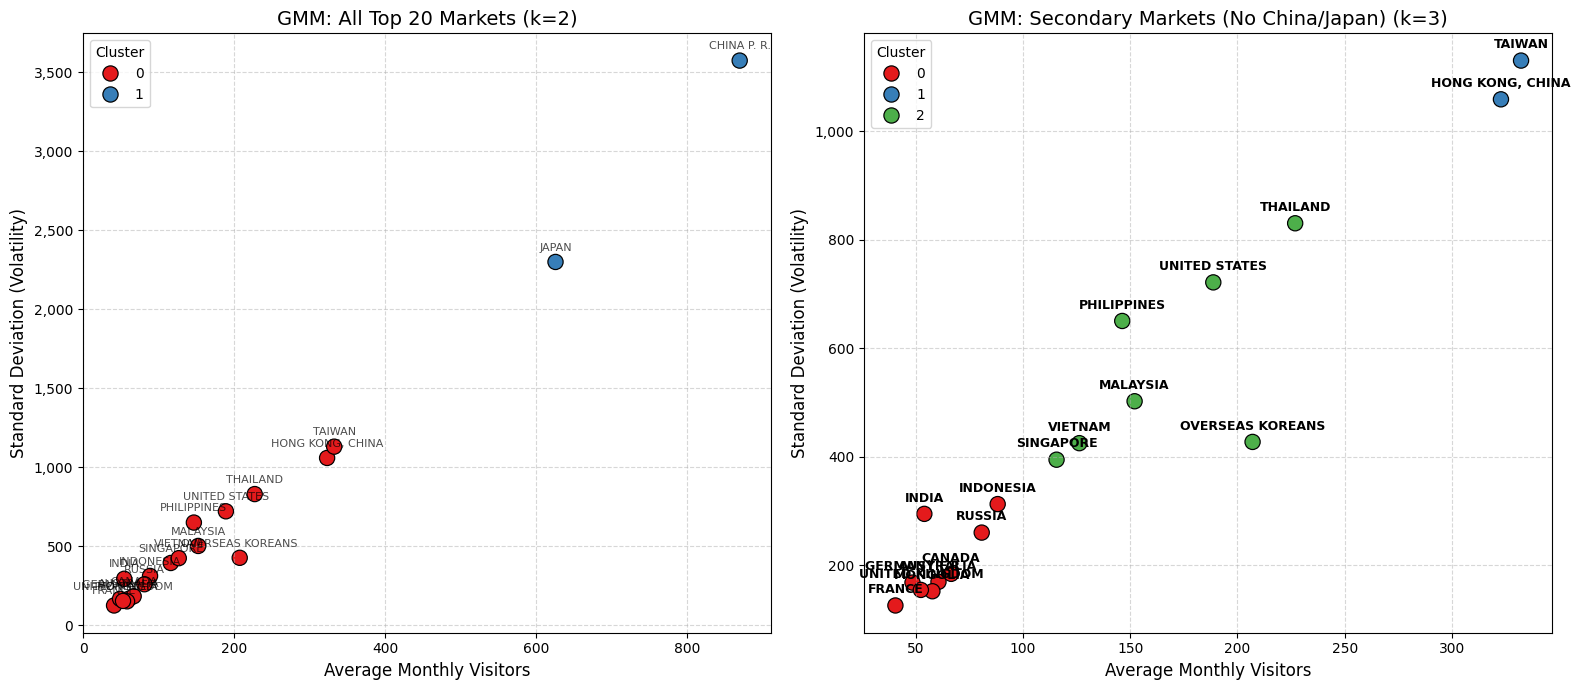

In [32]:
# VISUALIZATION (SIDE-BY-SIDE)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: All Markets
sns.scatterplot(data=profiles_all, x='Mean_Volume', y='Volatility', hue='Cluster', palette='Set1', s=120, edgecolor='black', ax=axes[0])
for i in range(profiles_all.shape[0]):
    axes[0].text(profiles_all['Mean_Volume'].iloc[i], profiles_all['Volatility'].iloc[i] + (profiles_all['Volatility'].max() * 0.02), 
                 profiles_all.index[i], fontsize=8, ha='center', alpha=0.7)
axes[0].set_title(f'GMM: All Top 20 Markets (k={best_k_all})', fontsize=14)
axes[0].set_xlabel('Average Monthly Visitors', fontsize=12)
axes[0].set_ylabel('Standard Deviation (Volatility)', fontsize=12)
axes[0].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[0].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Secondary Markets
sns.scatterplot(data=profiles_sec, x='Mean_Volume', y='Volatility', hue='Cluster', palette='Set1', s=120, edgecolor='black', ax=axes[1])
for i in range(profiles_sec.shape[0]):
    axes[1].text(profiles_sec['Mean_Volume'].iloc[i], profiles_sec['Volatility'].iloc[i] + (profiles_sec['Volatility'].max() * 0.02), 
                 profiles_sec.index[i], fontsize=9, ha='center', weight='bold')
axes[1].set_title(f'GMM: Secondary Markets (No China/Japan) (k={best_k_sec})', fontsize=14)
axes[1].set_xlabel('Average Monthly Visitors', fontsize=12)
axes[1].set_ylabel('Standard Deviation (Volatility)', fontsize=12)
axes[1].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**RQ4 Analysis:**
When attempting to cluster all global markets, the extreme volumes of China and Japan acted as "mega-outliers," skewing the spatial distance logic of the algorithm. By excluding these two markets, the GMM algorithm was able to analyze the remaining "Secondary Markets." Evaluated using the Silhouette Score, the model successfully identified distinct, mathematical sub-segments (e.g., low-volume/high-stability vs. mid-volume/mid-volatility) based entirely on behavior rather than geographic location.

**Conclusion:**
By combining logical geographic groupings (Short, Mid, and Long-Haul segments) with Unsupervised Machine Learning (Gaussian Mixture Models), this project successfully mapped the baseline travel behaviors of South Korean tourism. The statistical models proved that Long-Haul markets were highly predictable, which allowed for highly accurate forecasting. In contrast, markets closer to South Korea (Short Haul) are defined by skewed, highly volatile seasonal spikes. Ultimately, this analysis demonstrates that distance fundamentally alters travel behavior, requiring entirely different predictive approaches depending on the market being analyzed.